In [1]:
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy import special
from tqdm import tqdm
from math import floor
import statsmodels.api as sm

In [2]:
def gen():
    return int(np.random.random() * 10**6)

# 1. Генерация данных

In [3]:
def generator_uniform(n):
    return np.sort(np.random.uniform(-np.sqrt(3), np.sqrt(3), n))

def generator_normal(n):
    return np.sort(np.random.normal(0, 1, n))

def generator_exponential(n):
    return np.sort(stats.expon(scale=1, loc=-1).rvs(size=n, random_state=gen()))

# 2. Проверка гипотезы для медианы

In [4]:
a = 1
alpha, beta = 0.05, 0.05

In [7]:
n_values = [10, 50, 100, 150, 200, 500]

In [6]:
def fill_binom_sums(n, p):
    binom_sums[(n, p)] = []
    cum_sum = 0
    for m in range(n):
        cum_sum += special.comb(n, m) * np.pow(p, m) * np.pow(1 - p, n - m)
        binom_sums[(n, p)].append(cum_sum)

def get_median_interval(sample, q):
    n = sample.size
    k_1, k_2 = 0, n - 1

    binom_sum = binom_sums[(n, 0.5)]

    l, r = 0, n - 1
    while (r - l) > 1:
        m = l + (r - l) // 2
        if binom_sum[m] <= (1 - q) / 2:
            l = m
        else:
            r = m
    k_1 = l

    l, r = 0, n - 1
    while (r - l) > 1:
        m = l + (r - l) // 2
        if binom_sum[m] >= (1 + q) / 2:
            r = m
        else:
            l = m
    k_2 = r

    # sample is sorted!!!
    assert(0 <= k_1 <= n - 1)
    assert(0 <= k_2 <= n - 1)
    assert(sample[k_1] < sample[k_2])
    return [
        sample[k_1],
        sample[k_2]
    ]

In [9]:
binom_sums = {}
for n in n_values:
    fill_binom_sums(n, 0.5)

In [10]:
def check_hypothesis(sample, a, alpha=0.05, beta=0.05):
    l_alpha, r_alpha = get_median_interval(sample, q=1-alpha)
    l_beta, r_beta  = get_median_interval(sample, q=1-beta)

    if l_beta <= r_beta <= a:
        return 0
    elif a <= l_alpha:
        return 1
    else:
        return 1

In [11]:
def calc_I_error(generator, sample_size, a, experiments_count=10**3):
    I_error_count = 0
    for _ in range(experiments_count):
        sample = generator(sample_size)
        I_error_count += check_hypothesis(sample, a, alpha, beta)
    return I_error_count / experiments_count

In [12]:
I_errors = {
    'uniform' : [calc_I_error(generator_uniform, n, 0.5) for n in tqdm(n_values)],
    'normal' : [calc_I_error(generator_normal, n, 0.5) for n in tqdm(n_values)],
    'exponential' : [calc_I_error(generator_exponential, n, 0.5) for n in tqdm(n_values)],
}

100%|██████████| 6/6 [00:06<00:00,  1.08s/it]


In [30]:
import statsmodels.stats.proportion as proportion

I_errors_intervals = {
    key : np.array([np.array(proportion.proportion_confint(value * 10**3, 10**3, method='wilson')) for value in I_errors[key]]) for key in I_errors.keys()
}

In [34]:
I_errors_intervals['uniform'][:, 1]

array([0.9252953 , 0.54585913, 0.216528  , 0.07424958, 0.02460098,
       0.00382676])

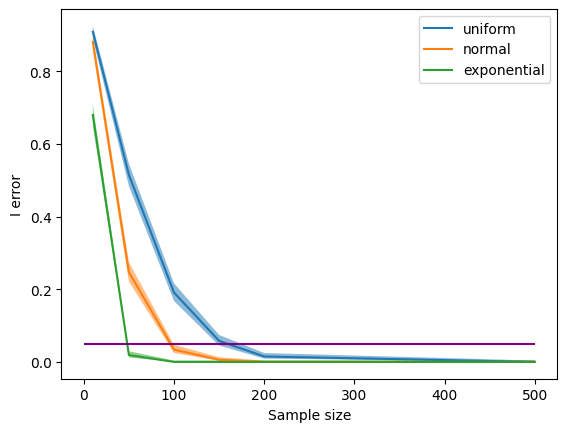

<Figure size 640x480 with 0 Axes>

In [46]:
data_1 = pd.DataFrame({
    'I error' : I_errors['uniform'],
    'Sample size' : n_values
})

data_2 = pd.DataFrame({
    'I error' : I_errors['normal'],
    'Sample size' : n_values
})

data_3 = pd.DataFrame({
    'I error' : I_errors['exponential'],
    'Sample size' : n_values
})

sns.lineplot(data=data_1, y='I error', x='Sample size', label='uniform')
sns.lineplot(data=data_2, y='I error', x='Sample size', label='normal')
sns.lineplot(data=data_3, y='I error', x='Sample size', label='exponential')

plt.fill_between(n_values, I_errors_intervals['uniform'][:, 0], I_errors_intervals['uniform'][:, 1], alpha=0.5)
plt.fill_between(n_values, I_errors_intervals['normal'][:, 0], I_errors_intervals['normal'][:, 1], alpha=0.5)
plt.fill_between(n_values, I_errors_intervals['exponential'][:, 0], I_errors_intervals['exponential'][:, 1], alpha=0.5)
plt.hlines(alpha, 0, 500, color='purple')
plt.show()
plt.tight_layout()

# 3. Двигаем истинную медиану

In [47]:
biases = np.arange(0.2, 2*a + 0.2, 0.2).tolist()

In [48]:
def get_generator_uniform_biased(bias):
    def generator_uniform_biased(n):
        return np.sort(np.random.uniform(-np.sqrt(3), np.sqrt(3), n)) + bias
    return generator_uniform_biased

def get_generator_normal_biased(bias):
    def generator_normal_biased(n):
        return np.sort(np.random.normal(bias, 1, n))
    return generator_normal_biased

def get_generator_exponential_biased(bias):
    def generator_exponential_biased(n):
        return np.sort(stats.expon(scale=1, loc=-1 + bias).rvs(size=n, random_state=gen()))
    return generator_exponential_biased

In [49]:
def calc_I_error_biased(generator, bias, sample_size, a, experiments_count=10**3):
    I_error_count = 0
    for _ in range(experiments_count):
        sample = generator(sample_size)
        I_error_count += 1 if check_hypothesis(sample, a) == 1 and bias <= a else 0
    return I_error_count / experiments_count

In [50]:
I_errors = {'n=10' : {
    'uniform' : [calc_I_error_biased(get_generator_uniform_biased(bias), bias, 10, 0.5) for bias in tqdm(biases)],
    'normal' : [calc_I_error_biased(get_generator_normal_biased(bias), bias, 10, 0.5) for bias in tqdm(biases)],
    'exponential' : [calc_I_error_biased(get_generator_exponential_biased(bias), bias, 10, 0.5) for bias in tqdm(biases)],
},
'n=50' : {
    'uniform' : [calc_I_error_biased(get_generator_uniform_biased(bias), bias, 50, 0.5) for bias in tqdm(biases)],
    'normal' : [calc_I_error_biased(get_generator_normal_biased(bias), bias, 50, 0.5) for bias in tqdm(biases)],
    'exponential' : [calc_I_error_biased(get_generator_exponential_biased(bias), bias, 50, 0.5) for bias in tqdm(biases)],
},
'n=100' : {
    'uniform' : [calc_I_error_biased(get_generator_uniform_biased(bias), bias, 100, 0.5) for bias in tqdm(biases)],
    'normal' : [calc_I_error_biased(get_generator_normal_biased(bias), bias, 100, 0.5) for bias in tqdm(biases)],
    'exponential' : [calc_I_error_biased(get_generator_exponential_biased(bias), bias, 100, 0.5) for bias in tqdm(biases)],
},
'n=200' : {
    'uniform' : [calc_I_error_biased(get_generator_uniform_biased(bias), bias, 200, 0.5) for bias in tqdm(biases)],
    'normal' : [calc_I_error_biased(get_generator_normal_biased(bias), bias, 200, 0.5) for bias in tqdm(biases)],
    'exponential' : [calc_I_error_biased(get_generator_exponential_biased(bias), bias, 200, 0.5) for bias in tqdm(biases)],
},
'n=500' : {
    'uniform' : [calc_I_error_biased(get_generator_uniform_biased(bias), bias, 200, 0.5) for bias in tqdm(biases)],
    'normal' : [calc_I_error_biased(get_generator_normal_biased(bias), bias, 200, 0.5) for bias in tqdm(biases)],
    'exponential' : [calc_I_error_biased(get_generator_exponential_biased(bias), bias, 200, 0.5) for bias in tqdm(biases)],
},
}

100%|██████████| 10/10 [00:15<00:00,  1.58s/it]


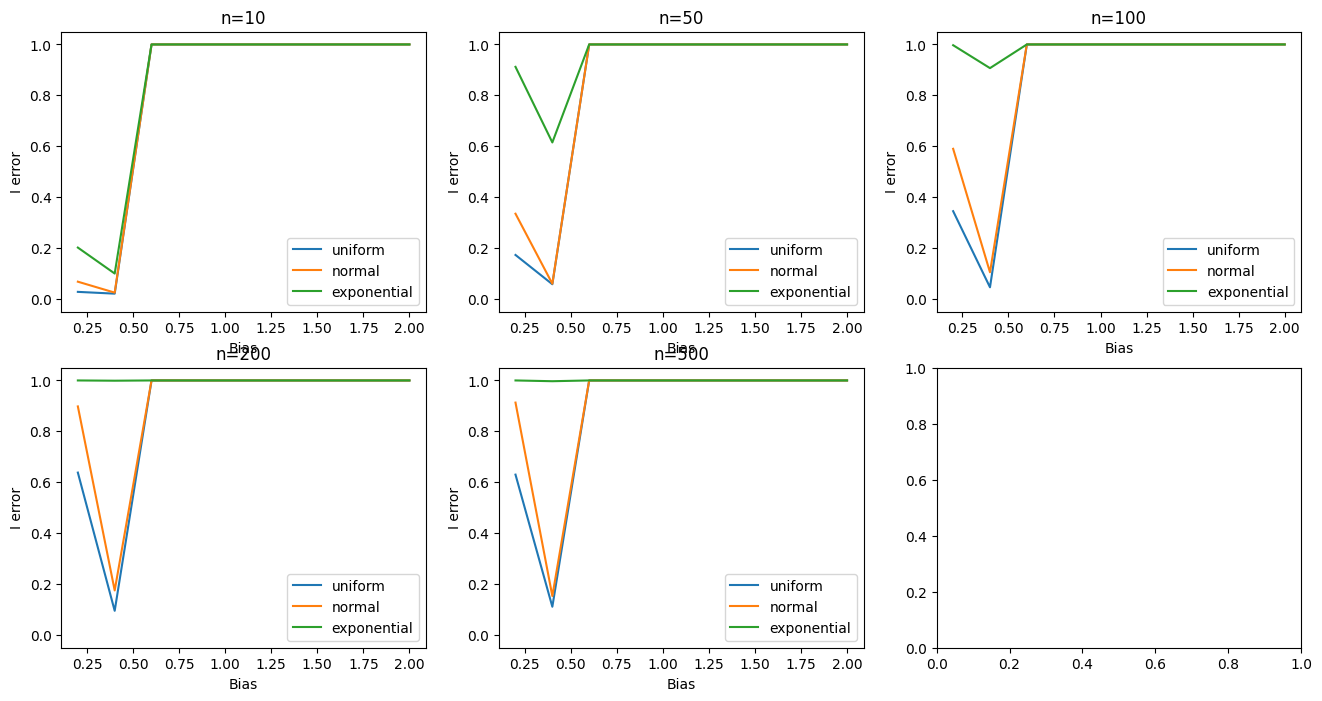

<Figure size 640x480 with 0 Axes>

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i in range(2):
    for j in range(3):
        if 3*i + j == 5:
            continue
        name = list(I_errors.keys())[3*i + j]
        I_errors_subset = I_errors[name]
        data_1 = pd.DataFrame({
            'I error' : [1 - item for item in I_errors_subset['uniform']],
            'Bias' : biases
        })
        data_2 = pd.DataFrame({
            'I error' : [1 - item for item in I_errors_subset['normal']],
            'Bias' : biases
        })
        data_3 = pd.DataFrame({
            'I error' : [1 - item for item in I_errors_subset['exponential']],
            'Bias' : biases
        })

        sns.lineplot(data=data_1, y='I error', x='Bias', ax=axes[i][j], label='uniform')
        sns.lineplot(data=data_2, y='I error', x='Bias', ax=axes[i][j], label='normal')
        sns.lineplot(data=data_3, y='I error', x='Bias', ax=axes[i][j], label='exponential')

        axes[i][j].set_title(name)
        axes[i][j].set_ylim(-0.05, 1.05)

plt.show()
plt.tight_layout()

# 4.1. Проверка гипотезы для дисперсии

In [55]:
from scipy.stats import chi2

def get_variance_interval(sample, alpha):
    n = sample.size
    D = np.var(sample)
    return [
        D * (n - 1) / chi2.ppf(1 - (alpha / 2), n - 1),
        D * (n - 1) / chi2.ppf((alpha / 2), n - 1),
    ]

In [56]:
def check_hypothesis_var(sample, a, alpha=0.05, beta=0.05):
    l_alpha, r_alpha = get_variance_interval(sample, alpha)
    l_beta, r_beta  = get_variance_interval(sample, alpha)

    if l_beta <= r_beta <= a:
        return 0
    elif a <= l_alpha:
        return 1
    else:
        return 1

In [57]:
def calc_I_error_var(generator, sample_size, a, experiments_count=10**3):
    I_error_count = 0
    for _ in range(experiments_count):
        sample = generator(sample_size)
        I_error_count += check_hypothesis_var(sample, a, alpha, beta)
    return I_error_count / experiments_count

In [66]:
I_errors_var = {
    'uniform' : [calc_I_error_var(generator_uniform, n, 2) for n in tqdm(n_values)],
    'normal' : [calc_I_error_var(generator_normal, n, 2) for n in tqdm(n_values)],
    'exponential' : [calc_I_error_var(generator_exponential, n, 2) for n in tqdm(n_values)],
}

100%|██████████| 6/6 [00:11<00:00,  1.96s/it]


In [67]:
import statsmodels.stats.proportion as proportion

I_errors_intervals_var = {
    key : np.array([np.array(proportion.proportion_confint(value * 10**3, 10**3, method='wilson')) for value in I_errors_var[key]]) for key in I_errors_var.keys()
}

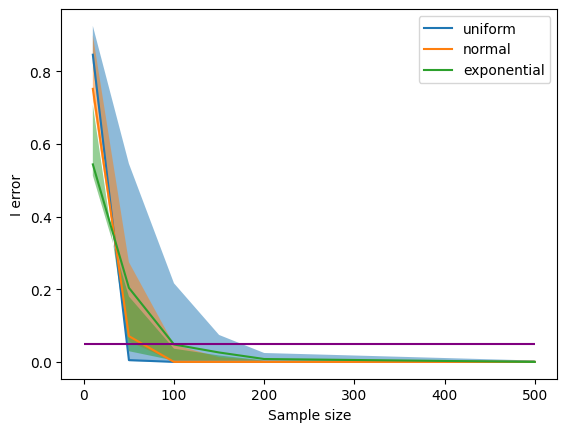

<Figure size 640x480 with 0 Axes>

In [68]:
data_1 = pd.DataFrame({
    'I error' : I_errors_var['uniform'],
    'Sample size' : n_values
})

data_2 = pd.DataFrame({
    'I error' : I_errors_var['normal'],
    'Sample size' : n_values
})

data_3 = pd.DataFrame({
    'I error' : I_errors_var['exponential'],
    'Sample size' : n_values
})

sns.lineplot(data=data_1, y='I error', x='Sample size', label='uniform')
sns.lineplot(data=data_2, y='I error', x='Sample size', label='normal')
sns.lineplot(data=data_3, y='I error', x='Sample size', label='exponential')

plt.fill_between(n_values, I_errors_intervals_var['uniform'][:, 0], I_errors_intervals['uniform'][:, 1], alpha=0.5)
plt.fill_between(n_values, I_errors_intervals_var['normal'][:, 0], I_errors_intervals['normal'][:, 1], alpha=0.5)
plt.fill_between(n_values, I_errors_intervals_var['exponential'][:, 0], I_errors_intervals['exponential'][:, 1], alpha=0.5)
plt.hlines(alpha, 0, 500, color='purple')
plt.show()
plt.tight_layout()

# 5.1. Проверка гипотезы для 99% квантиля

In [ ]:
from scipy.stats import chi2

def get_quantile_interval(sample, alpha):
    n = sample.size
    D = np.var(sample)
    return [
        D * (n - 1) / chi2.ppf(1 - (alpha / 2), n - 1),
        D * (n - 1) / chi2.ppf((alpha / 2), n - 1),
    ]

In [ ]:
def check_hypothesis_var(sample, a, alpha=0.05, beta=0.05):
    l_alpha, r_alpha = get_variance_interval(sample, alpha)
    l_beta, r_beta  = get_variance_interval(sample, alpha)

    if l_beta <= r_beta <= a:
        return 0
    elif a <= l_alpha:
        return 1
    else:
        return 1

In [ ]:
def calc_I_error_var(generator, sample_size, a, experiments_count=10**3):
    I_error_count = 0
    for _ in range(experiments_count):
        sample = generator(sample_size)
        I_error_count += check_hypothesis_var(sample, a, alpha, beta)
    return I_error_count / experiments_count

In [ ]:
I_errors_var = {
    'uniform' : [calc_I_error_var(generator_uniform, n, 2) for n in tqdm(n_values)],
    'normal' : [calc_I_error_var(generator_normal, n, 2) for n in tqdm(n_values)],
    'exponential' : [calc_I_error_var(generator_exponential, n, 2) for n in tqdm(n_values)],
}

100%|██████████| 6/6 [00:11<00:00,  1.96s/it]


In [ ]:
import statsmodels.stats.proportion as proportion

I_errors_intervals_var = {
    key : np.array([np.array(proportion.proportion_confint(value * 10**3, 10**3, method='wilson')) for value in I_errors_var[key]]) for key in I_errors_var.keys()
}

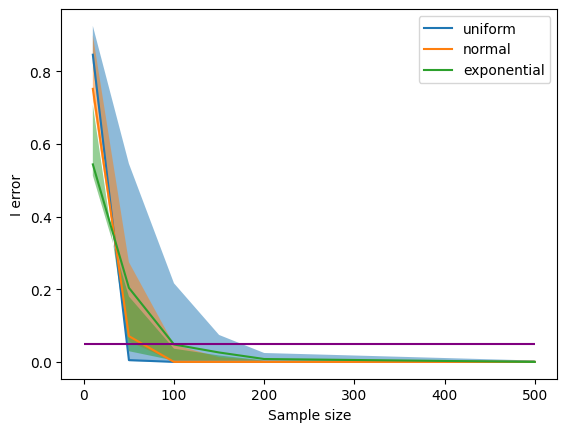

<Figure size 640x480 with 0 Axes>

In [ ]:
data_1 = pd.DataFrame({
    'I error' : I_errors_var['uniform'],
    'Sample size' : n_values
})

data_2 = pd.DataFrame({
    'I error' : I_errors_var['normal'],
    'Sample size' : n_values
})

data_3 = pd.DataFrame({
    'I error' : I_errors_var['exponential'],
    'Sample size' : n_values
})

sns.lineplot(data=data_1, y='I error', x='Sample size', label='uniform')
sns.lineplot(data=data_2, y='I error', x='Sample size', label='normal')
sns.lineplot(data=data_3, y='I error', x='Sample size', label='exponential')

plt.fill_between(n_values, I_errors_intervals_var['uniform'][:, 0], I_errors_intervals['uniform'][:, 1], alpha=0.5)
plt.fill_between(n_values, I_errors_intervals_var['normal'][:, 0], I_errors_intervals['normal'][:, 1], alpha=0.5)
plt.fill_between(n_values, I_errors_intervals_var['exponential'][:, 0], I_errors_intervals['exponential'][:, 1], alpha=0.5)
plt.hlines(alpha, 0, 500, color='purple')
plt.show()
plt.tight_layout()